In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))
from battery_analysis import *   # provides: start_plot, calculate_error, load_cycle_life_predictions,
                                 #           plot_cycle_retention, calculate_eol_cycles, find_year_at_threshold,
                                 #           get_retention_matrix, get_final_capacity, and all warranty functions

`start_plot` and `calculate_error` are provided by `battery_analysis`.

# Functions from `battery_analysis`

All reusable functions (`start_plot`, `calculate_error`, `load_cycle_life_predictions`,
`plot_cycle_retention`, `calculate_eol_cycles`) are imported from
`../battery_analysis.py`. No local redefinitions needed.

`plot_results` → replaced by `plot_cycle_retention(cycle_life_predictions, retention_exp=None)` from `battery_analysis`.

In [11]:
results_dir = '1C-CCCV-25-SOC0_100'

# Monte Carlo Parameters

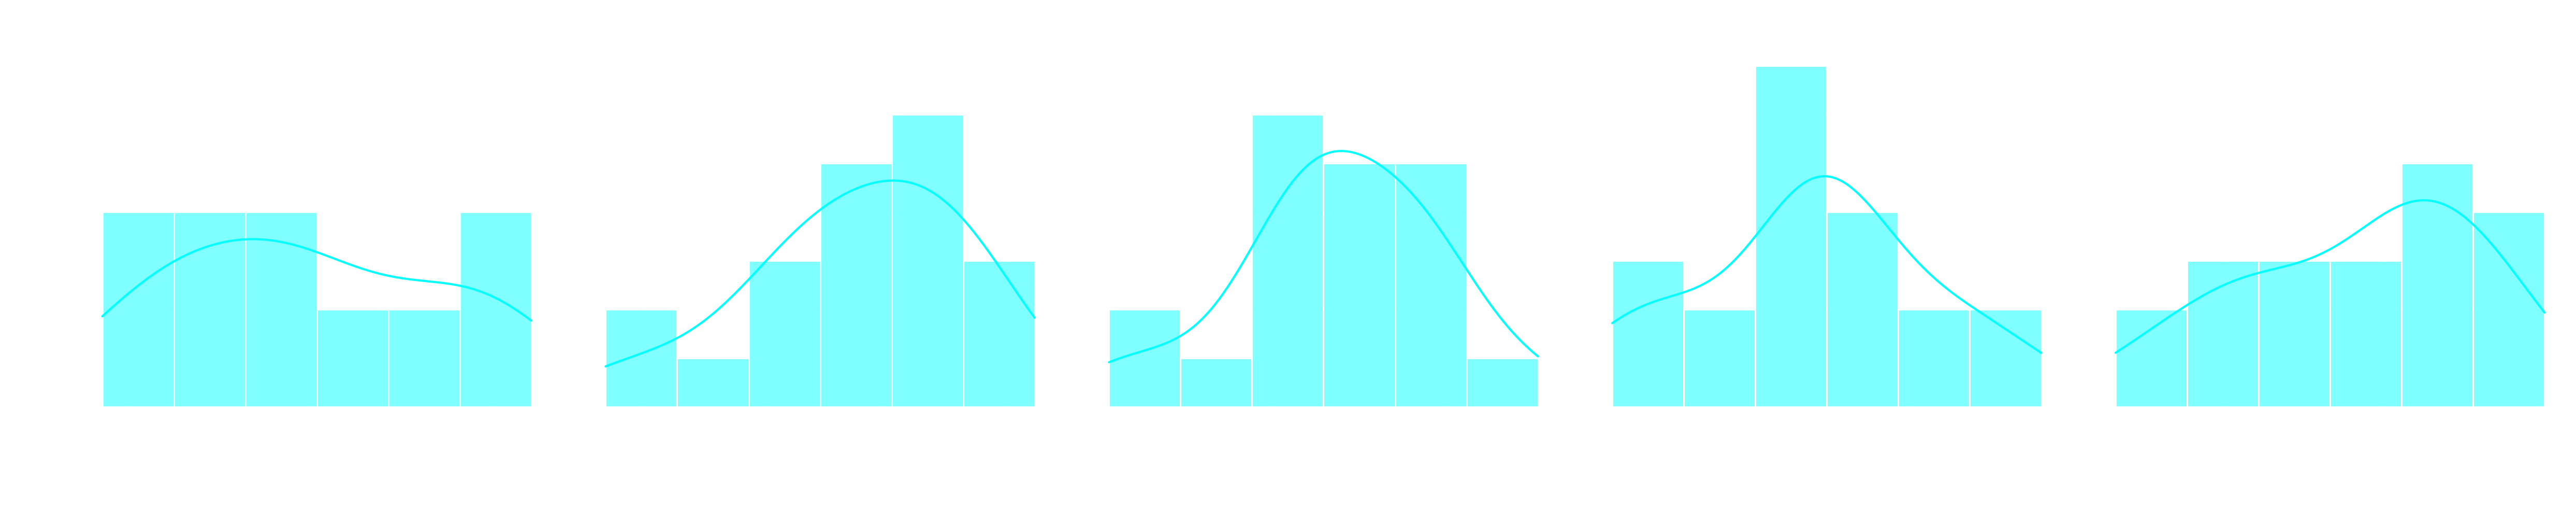

In [12]:
## Simulation data
monte_carlo_summary = pd.read_csv(f'./{results_dir}/monte_carlo_parallel_summary.csv')
params = ['dOCV', 'dQ', 'dR0', 'dR1', 'dR2']
y_col = 'Final_Capacity'

with sns.axes_style('darkgrid'):
    fig, axes = plt.subplots(1, 5, figsize=(25, 5), dpi=200, sharey=True)
    fig.patch.set_alpha(0.0)
    
    for i, param in enumerate(params):
        ax = axes[i]
        
        # Calculate correlation
        corr = monte_carlo_summary[param].corr(monte_carlo_summary[y_col])
        
        # Plot histogram with KDE
        sns.histplot(data=monte_carlo_summary, x=param, kde=True, 
                     color='cyan', edgecolor='white', alpha=0.5, ax=ax)
        
        # Styling
        ax.set_title(rf'$\bf {param}$', color='white', fontsize=30)
        ax.set_xlabel(rf'$\bf {param} (\%)$', color='white', fontsize=30)
        ax.set_ylabel(rf'$\bf Count$', color='white', fontsize=30)
        
        ax.patch.set_alpha(0.0)
        ax.tick_params(colors='white', labelsize=25)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

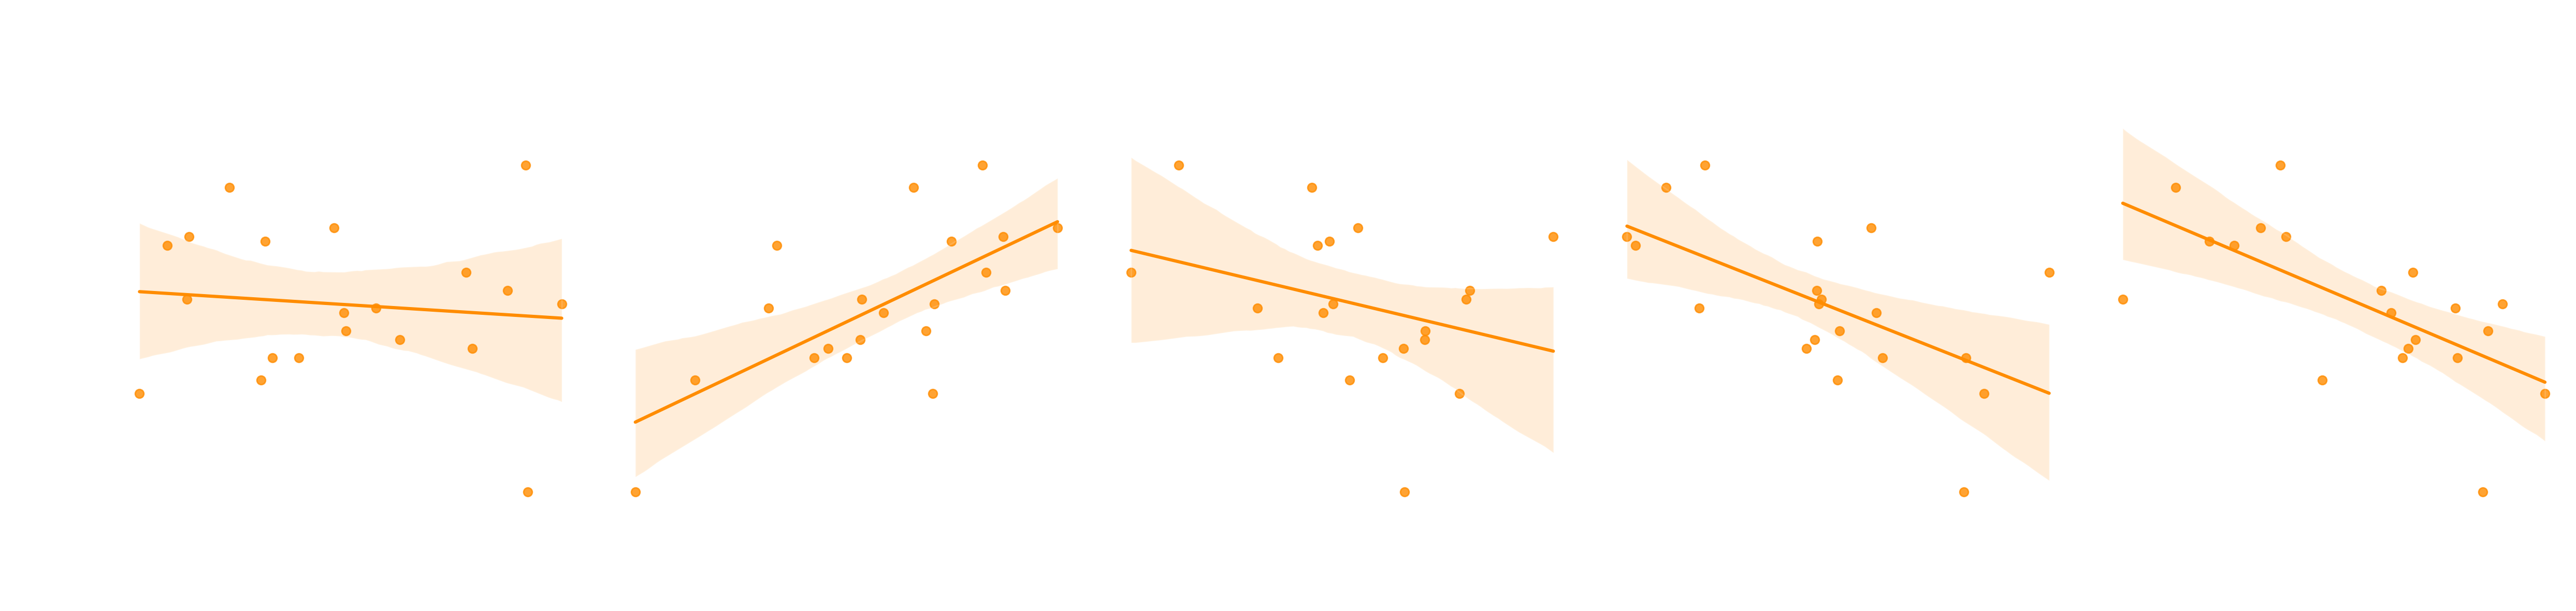

In [13]:
params = ['dOCV', 'dQ', 'dR0', 'dR1', 'dR2']
y_col = 'Final_Capacity'

with sns.axes_style('darkgrid'):
    fig, axes = plt.subplots(1, 5, figsize=(25, 6), dpi=200, sharey=True)
    fig.patch.set_alpha(0.0)
    
    for i, param in enumerate(params):
        ax = axes[i]
        
        # Calculate correlation
        corr = monte_carlo_summary[param].corr(monte_carlo_summary[y_col])
        
        # Plot histogram with KDE
        sns.regplot(data=monte_carlo_summary, x=param, y=y_col, 
                     color='darkorange',ax=ax)
        
        # Styling
        ax.set_title(rf'$\begin{{array}}{{c}} \bf Q_{{end}}\ v.s\ {param} \\ \bf (r={corr:.2f}) \end{{array}}$', 
                     color='white', fontsize=30, pad=30)
        ax.set_xlabel(rf'$\bf {param} (\%)$', color='white', fontsize=30)
        
        if i == 0:
            ax.set_ylabel(rf'$\bf Q_{{end}} (Ah)$', color='white', fontsize=30)
        else:
            ax.set_ylabel('')
        
        ax.patch.set_alpha(0.0)
        ax.tick_params(colors='white', labelsize=25)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# $25 \degree C$

## Simulation data

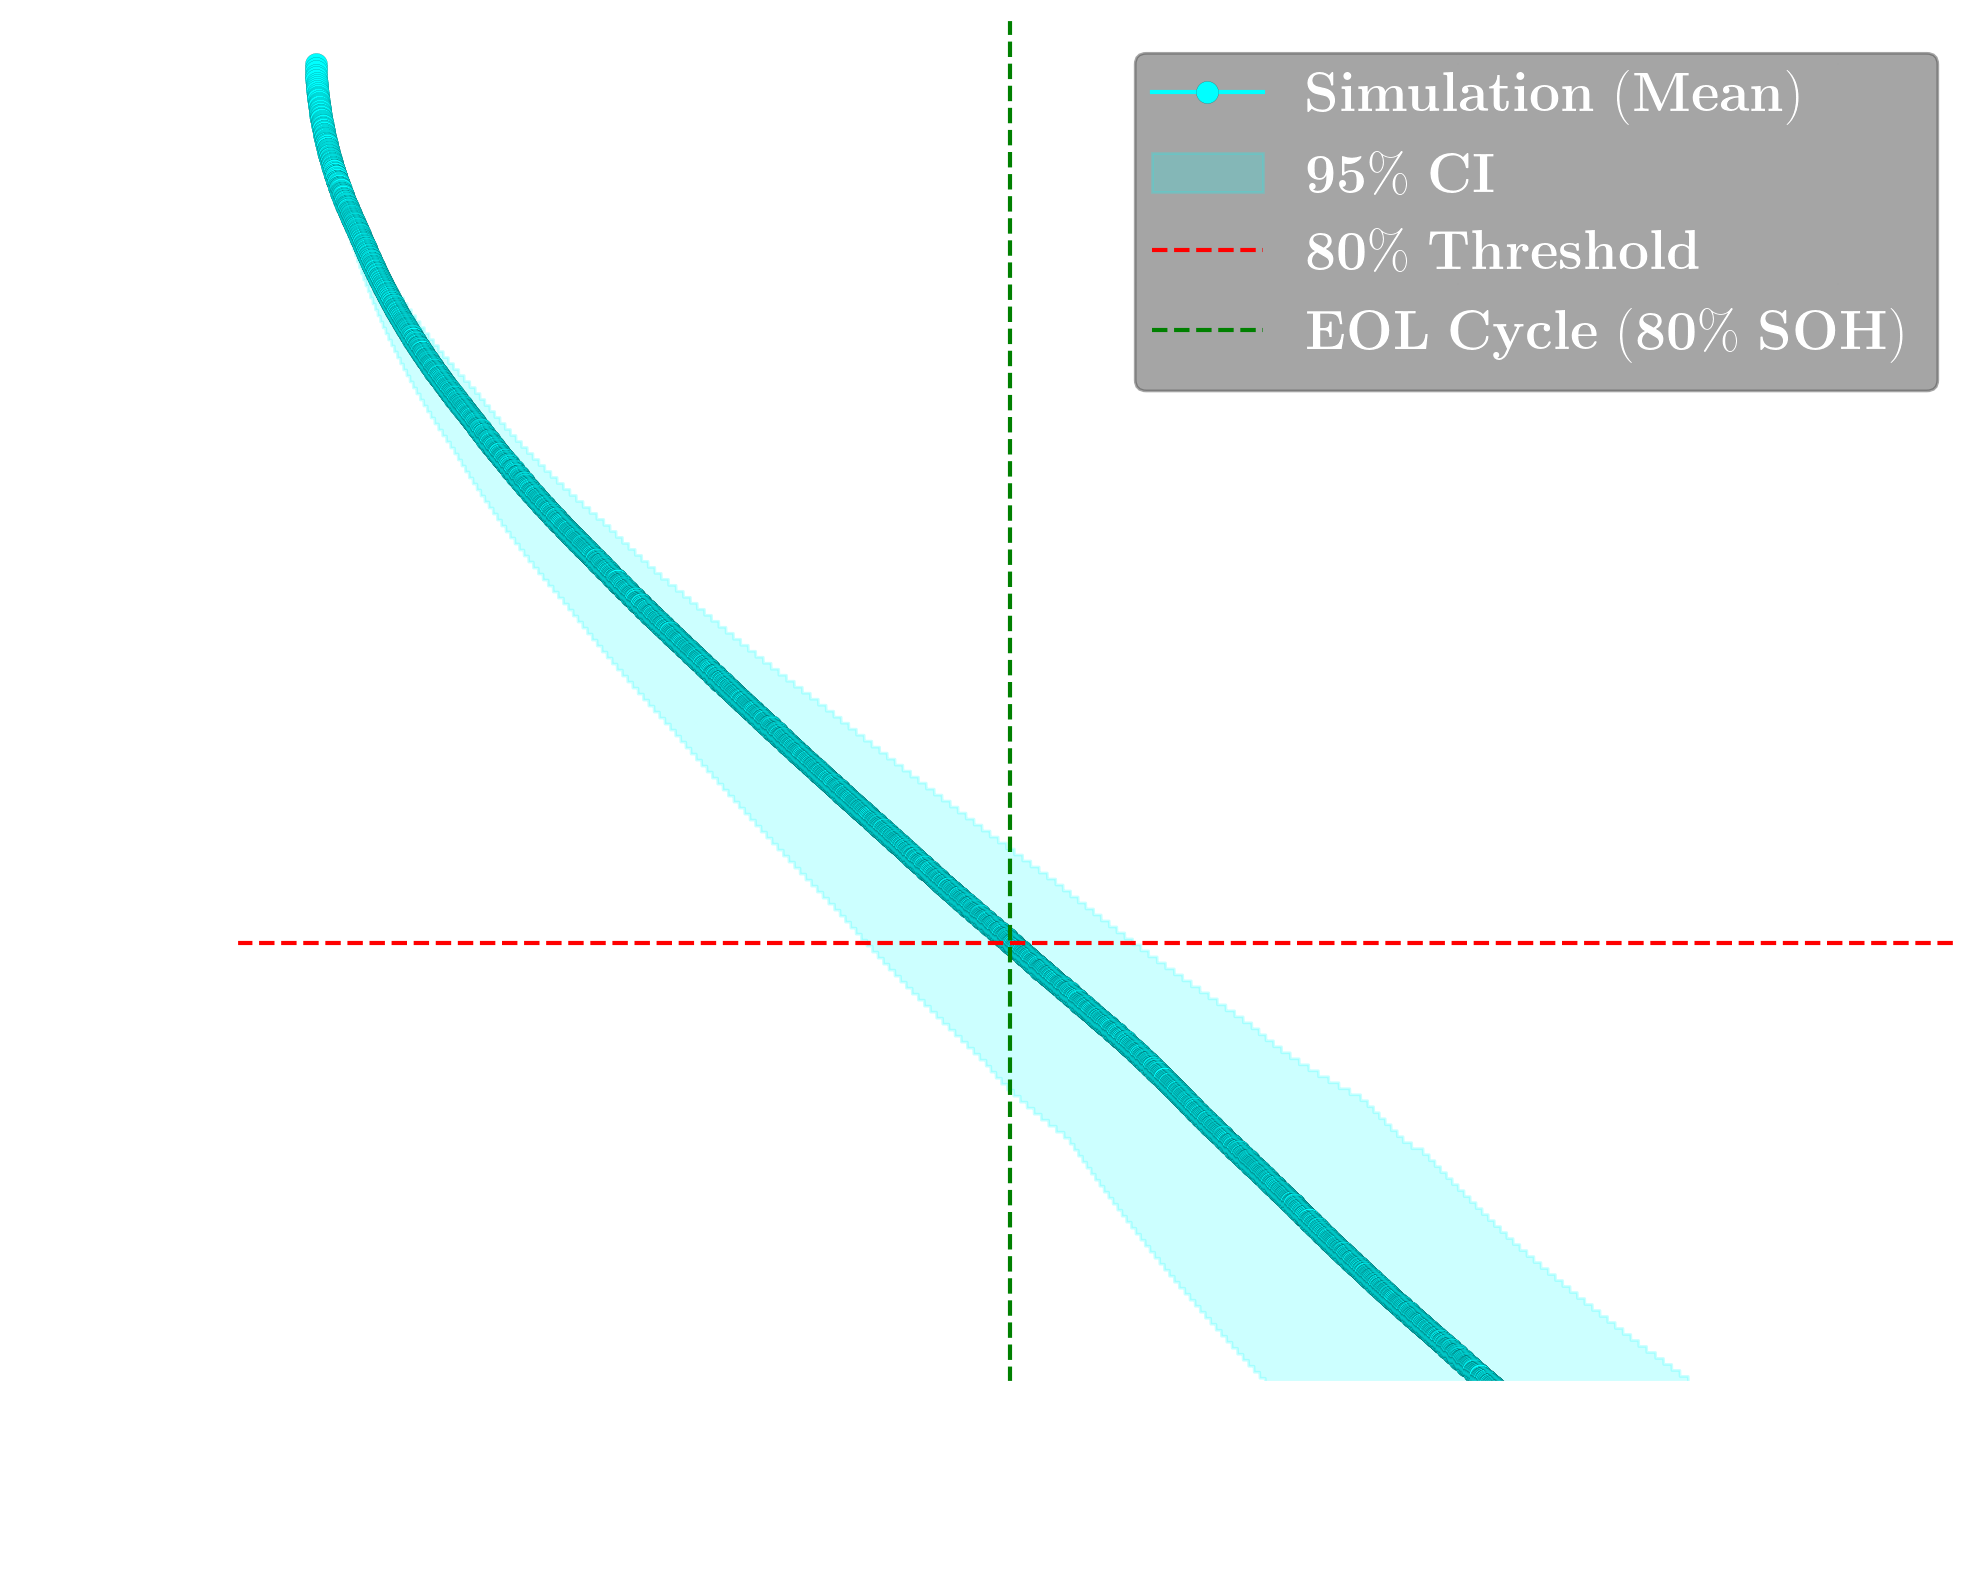

(<Figure size 2000x1600 with 1 Axes>,
 <Axes: xlabel='$\\bf Cycle\\ number$', ylabel='$\\bf Retention\\ (\\%)$'>)

In [15]:
cycle_life_predictions_25 = load_cycle_life_predictions(f'{results_dir}/confidence_interval_data.csv', cycle_min=0)
plot_cycle_retention(cycle_life_predictions_25, retention_exp=None, threshold=80)